# Marketing Campaign Analysis: EDA and Hypothesis Testing

**Author:** Sandra Hershey-Zagrans
**Course:** UTD AI/ML Bootcamp, Unit 2 Project

This analysis examines 2,240 customers of a food and beverage retailer through the lens of the four Ps of the marketing mix. In this dataset, **People** is the demographic fields (birth year, education, marital status, income), **Product** is the spending columns for wine, fruit, meat, fish, sweets, and gold, **Place** is the purchase channels (web, catalog, store), and **Promotion** is the campaign acceptance fields.

The work proceeds in two phases: exploratory data analysis (cleaning, imputation, feature engineering, encoding, correlation), then formal hypothesis testing on four questions about customer behavior.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")

df = pd.read_csv("data/marketing_data.csv")
print(df.shape)
print([repr(c) for c in df.columns[:8]])   # repr exposes hidden whitespace
print(repr(df[" Income "].iloc[0]))
print(df.isna().sum()[df.isna().sum() > 0])

(2240, 28)
["'ID'", "'Year_Birth'", "'Education'", "'Marital_Status'", "' Income '", "'Kidhome'", "'Teenhome'", "'Dt_Customer'"]
'$84,835.00 '
Income     24
dtype: int64


In [2]:
# Fix column names, then Income, then dates
df.columns = df.columns.str.strip()

df["Income"] = (df["Income"]
                .str.replace("$", "", regex=False)
                .str.replace(",", "", regex=False)
                .astype(float))

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format="%m/%d/%y")

print("Income:", df["Income"].dtype, "| range:",
      f"${df['Income'].min():,.0f} to ${df['Income'].max():,.0f}")
print("Dates:", df["Dt_Customer"].min().date(), "to", df["Dt_Customer"].max().date())

Income: float64 | range: $1,730 to $666,666
Dates: 2012-07-30 to 2014-06-29


## Step 1: Import verification

Pandas loads almost anything without complaint, so the first job is catching what it loaded wrong. Printing column names with `repr()` exposed hidden characters, and three problems surfaced:

1. The income column was named `' Income '` with surrounding whitespace, making it unreachable by its expected name.
2. Income values were strings like `'$84,835.00 '`. With a dollar sign and comma present, pandas stored the column as text, so no arithmetic was possible.
3. `Dt_Customer` imported as a string rather than a date.

All three are now fixed: column names stripped, Income converted to float (range $1,730 to $666,666, and that maximum is a suspicious value we will revisit during outlier treatment), and dates parsed. Enrollment dates run July 2012 to June 2014, which establishes **2014 as the reference year** for the age calculation later.

One issue remains: **24 customers have missing income**, addressed next.

## Step 2: Category cleaning and income imputation

**Category cleaning.** `Marital_Status` contained three nonsense levels: Alone (3 customers), YOLO (2), and Absurd (2). All seven describe a person without a partner, so they were consolidated into Single. Education's five levels (Basic, 2n Cycle, Graduation, Master, PhD) are legitimate and carry a natural ordering, so they are kept as-is for ordinal encoding later.

**Why group-mean imputation.** The 24 missing incomes could have been filled with the global mean, but the group means show why that would be a mistake: average income ranges from about $9,500 (Basic education, divorced) to over $53,000 (2n Cycle, single). Education stratifies income heavily, so a single global fill value would assign some customers wildly unrealistic incomes. Instead, each missing value is filled with the mean income of customers sharing the same education and marital status, a conditional estimate that uses what we already know about the customer.

**The mechanics.** `groupby().transform("mean")` computes each group's mean and broadcasts it back to every row, producing a full-length series that `fillna()` consumes directly. All 24 missing values are now filled and the column is complete.

In [3]:
print(df["Education"].value_counts())
print(df["Marital_Status"].value_counts())

# Consolidate junk marital categories
df["Marital_Status"] = df["Marital_Status"].replace({
    "Alone": "Single", "Absurd": "Single", "YOLO": "Single"
})

# Group-mean income imputation: fill each missing value with the mean
# income of customers sharing the same education and marital status
print(df.groupby(["Education", "Marital_Status"])["Income"].mean().round(0))

df["Income"] = df["Income"].fillna(
    df.groupby(["Education", "Marital_Status"])["Income"].transform("mean")
)
print("Missing income after imputation:", df["Income"].isna().sum())

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64
Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
YOLO          2
Absurd        2
Name: count, dtype: int64
Education   Marital_Status
2n Cycle    Divorced          49395.0
            Married           46201.0
            Single            53674.0
            Together          44736.0
            Widow             51392.0
Basic       Divorced           9548.0
            Married           21960.0
            Single            18239.0
            Together          21240.0
            Widow             22123.0
Graduation  Divorced          54526.0
            Married           50800.0
            Single            51366.0
            Together          55758.0
            Widow             54977.0
Master      Divorced          50332.0
            Married           53286.0
            Single         

## Step 3: Feature engineering

Four derived variables, each a building block for the hypothesis tests ahead:

- **Total_Children** = Kidhome + Teenhome. Half the customers have exactly one child at home; 638 have none.
- **Age** = 2014 minus birth year. The reference year comes from the data itself: enrollment dates run through June 2014, so 2014 is when this snapshot was taken.
- **Total_Spending** = the sum of all six product columns (wine, fruit, meat, fish, sweets, gold). Mean spending is $606 with a standard deviation nearly as large, another right-skewed variable.
- **Total_Purchases** = web + catalog + store purchases. `NumDealsPurchases` is deliberately excluded: a deal purchase is a discount flag on a transaction that already happened through one of the three channels, so adding it would double-count.

**Two flags raised for the next step:** the maximum age is 121, with exactly three customers born in 1893, 1899, and 1900 while the next oldest is 74. These are almost certainly data entry errors. And the minimum for Total_Purchases is 0, meaning a few customers bought nothing through any channel, which will matter when computing per-channel purchase shares later.

In [4]:
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

# 2014 reference year: enrollment dates end June 2014, so that's the snapshot date
df["Age"] = 2014 - df["Year_Birth"]

mnt_cols = ["MntWines", "MntFruits", "MntMeatProducts",
            "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
df["Total_Spending"] = df[mnt_cols].sum(axis=1)

# Three channels only; deals purchases are a discount flag, not a channel
df["Total_Purchases"] = (df["NumWebPurchases"]
                         + df["NumCatalogPurchases"]
                         + df["NumStorePurchases"])

print(df[["Total_Children", "Age", "Total_Spending", "Total_Purchases"]].describe().round(1))
print("\nOldest customers:\n", df["Age"].sort_values(ascending=False).head(5))

       Total_Children     Age  Total_Spending  Total_Purchases
count          2240.0  2240.0          2240.0           2240.0
mean              1.0    45.2           605.8             12.5
std               0.8    12.0           602.2              7.2
min               0.0    18.0             5.0              0.0
25%               0.0    37.0            68.8              6.0
50%               1.0    44.0           396.0             12.0
75%               1.0    55.0          1045.5             18.0
max               3.0   121.0          2525.0             32.0

Oldest customers:
 513     121
827     115
2233    114
2171     74
1740     73
Name: Age, dtype: int64


## Step 4: Distributions and outlier treatment

The box plots and histograms surfaced two impossible values: three customers aged 114 to 121 (birth years 1893 to 1900, almost certainly 19xx typed as 18xx, since the next oldest customer is 74) and one income of exactly $666,666, a repdigit sitting half a million dollars above the next highest income of $162,397. That gap and that pattern mark it as a sentinel or placeholder, not a real salary.

**Treatment choice: targeted removal, not IQR capping.** Blanket IQR capping would also clip the legitimate incomes in the $150K range and the genuine big spenders in Total_Spending, whose right skew reflects real customer behavior rather than error. The guiding principle: remove what is impossible, keep what is merely unusual. Four rows were dropped (0.2% of the data), leaving 2,236 customers with Age spanning 18 to 74 and Income topping out at $162K.

The remaining skew in Income and Total_Spending is genuine and stays: a minority of affluent, high-spending customers is exactly the kind of structure the hypothesis tests should see.

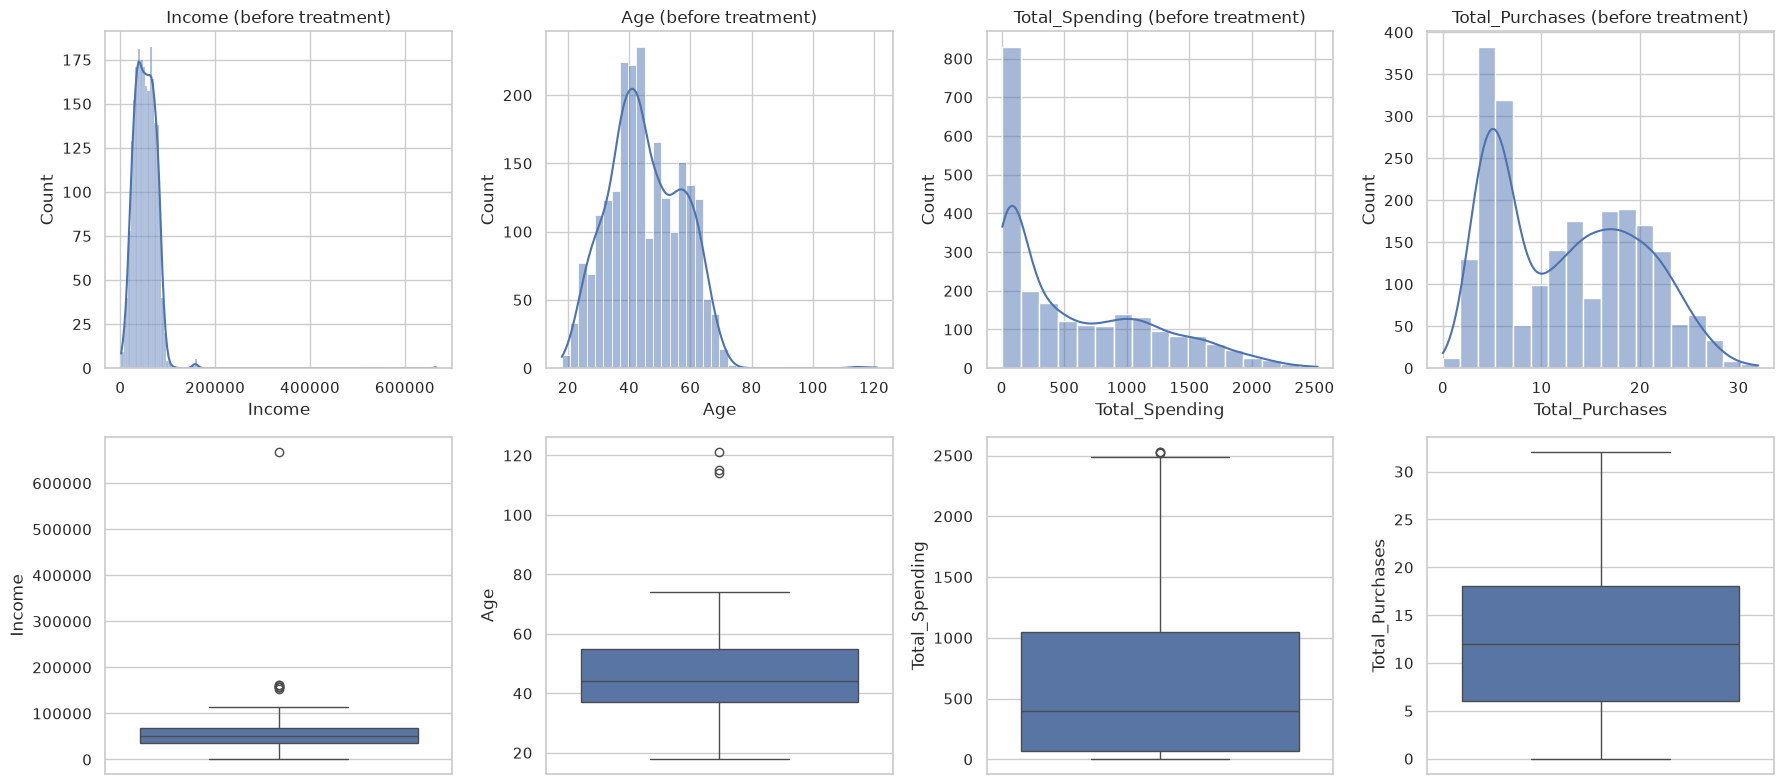

Top incomes: [666666.0, 162397.0, 160803.0, 157733.0, 157243.0]
Dropped 4 rows; 2236 remain


In [5]:
num_cols = ["Income", "Age", "Total_Spending", "Total_Purchases"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[0, i])
    axes[0, i].set_title(f"{col} (before treatment)")
    sns.boxplot(y=df[col], ax=axes[1, i])
plt.tight_layout()
plt.show()

print("Top incomes:", df["Income"].sort_values(ascending=False).head(5).tolist())

# Targeted removal of impossible values only
rows_before = len(df)
df = df[(df["Age"] < 100) & (df["Income"] < 600000)].copy()
print(f"Dropped {rows_before - len(df)} rows; {len(df)} remain")

## Steps 5 and 6: Encoding and correlation structure

**Encoding choices.** Education received ordinal encoding (Basic=0 through PhD=4) because its levels carry genuine rank. Marital status and country received one-hot encoding because their categories have no order; Married is not "more" than Single. A readable copy of the dataframe was preserved before encoding, since later visualizations need to group by the original Country and Marital_Status columns.

**Heatmap findings.** The heatmap uses a curated set of key variables, since a full 44-column matrix is unreadable. Four relationships stand out:

1. **Income drives spending** (r = 0.79), the strongest demographic relationship in the data.
2. **Children suppress spending** (r = -0.50). Each child at home is associated with sharply lower discretionary purchases.
3. **Web visits anti-correlate with spending** (r = -0.50). The heaviest website browsers spend the least, suggesting a deal-hunting segment distinct from affluent low-browsing buyers.
4. **Age and education barely correlate with spending** (both r = 0.11).

Two of these preview the hypothesis tests ahead: the weak age relationships bear on the claim that older customers prefer stores, and the fact that all three purchase channels correlate positively with one another bears directly on the cannibalization question.

In [6]:
# Keep a readable copy for the visualization section, where we still
# need actual Country and Marital_Status columns to group by
df_readable = df.copy()

# Ordinal: Education has natural rank
edu_order = {"Basic": 0, "2n Cycle": 1, "Graduation": 2, "Master": 3, "PhD": 4}
df["Education_Ord"] = df["Education"].map(edu_order)

# One-hot: Marital_Status and Country have no rank
df = pd.get_dummies(df, columns=["Marital_Status", "Country"],
                    prefix=["Marital", "Country"], dtype=int)
print("Shape after encoding:", df.shape)

Shape after encoding: (2236, 44)


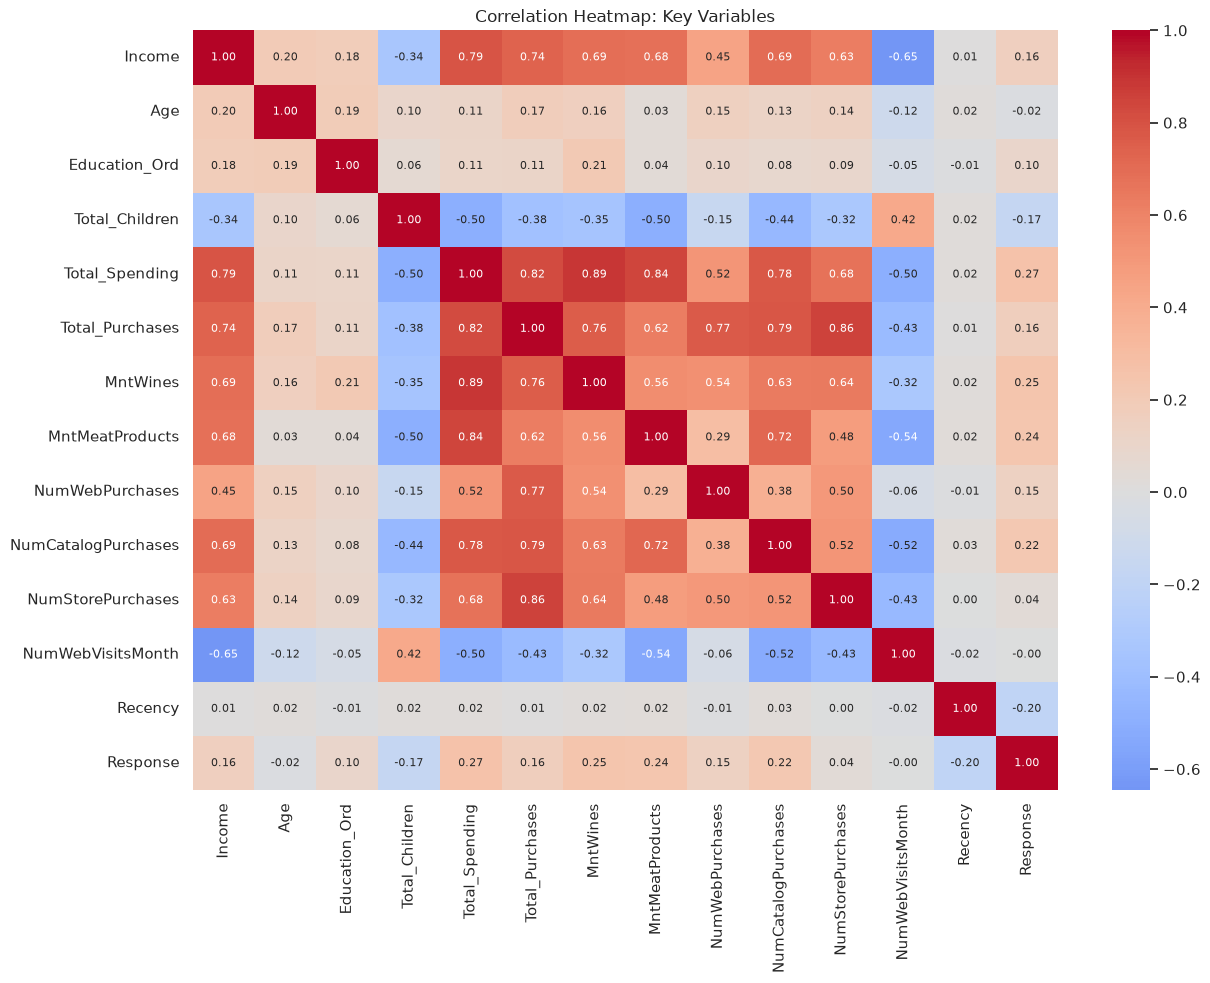

In [7]:
key_cols = ["Income", "Age", "Education_Ord", "Total_Children", "Total_Spending",
            "Total_Purchases", "MntWines", "MntMeatProducts",
            "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases",
            "NumWebVisitsMonth", "Recency", "Response"]

plt.figure(figsize=(13, 10))
sns.heatmap(df[key_cols].corr(), cmap="coolwarm", center=0,
            annot=True, fmt=".2f", annot_kws={"size": 8})
plt.title("Correlation Heatmap: Key Variables")
plt.tight_layout()
plt.show()

## Step 7: Hypothesis testing

### Hypothesis 1: Older customers prefer in-store shopping

**H0:** Older customers devote the same or a smaller share of their purchases to physical stores than younger customers.
**HA:** Older customers devote a greater share of their purchases to physical stores.

**Design notes.** The test uses purchase *share* rather than raw counts, because older customers might simply buy more of everything; a preference claim is about proportion, not volume. Six customers with zero total purchases were excluded since a share is undefined for them. The split is at the median age (44), and Welch's t-test is used since it does not assume equal group variances.

**Results.** Age correlates weakly and positively with all three channels (r between 0.125 and 0.154), and in fact correlates slightly more with web purchases than store purchases. The share comparison runs opposite to the hypothesis: older customers average a 49.1% store share versus 51.9% for younger customers. The one-sided test returns p = 1.0000, meaning the data is maximally inconsistent with the direction the hypothesis predicted (the reversed difference is itself statistically significant, t = -4.44).

**Conclusion: fail to reject H0, and the evidence points the opposite way.** Older customers in this dataset are, if anything, marginally less store-oriented than younger ones. The assumption that lower technological proficiency drives seniors toward in-store shopping is not supported. Marketing strategies should not segment channel campaigns by age.

In [8]:
# H1 — H0: older customers' store share of purchases <= younger customers'
#      HA: older customers devote a GREATER share of purchases to stores

# Angle 1: does age correlate with any channel?
for ch in ["NumStorePurchases", "NumWebPurchases", "NumCatalogPurchases"]:
    r, p = stats.pearsonr(df["Age"], df[ch])
    print(f"Age vs {ch}: r = {r:+.3f}, p = {p:.4f}")

# Angle 2: store share of purchases, older vs younger (median split)
valid = df[df["Total_Purchases"] > 0].copy()   # exclude zero-purchase customers
valid["Store_Share"] = valid["NumStorePurchases"] / valid["Total_Purchases"]

median_age = valid["Age"].median()
older = valid[valid["Age"] > median_age]["Store_Share"]
younger = valid[valid["Age"] <= median_age]["Store_Share"]
print(f"\nOlder mean store share:   {older.mean():.3f}")
print(f"Younger mean store share: {younger.mean():.3f}")

t, p = stats.ttest_ind(older, younger, equal_var=False, alternative="greater")
print(f"Welch t-test (one-sided): t = {t:.3f}, p = {p:.4f}")

Age vs NumStorePurchases: r = +0.139, p = 0.0000
Age vs NumWebPurchases: r = +0.154, p = 0.0000
Age vs NumCatalogPurchases: r = +0.125, p = 0.0000

Older mean store share:   0.491
Younger mean store share: 0.519
Welch t-test (one-sided): t = -4.438, p = 1.0000


### Hypothesis 2: Customers with children prefer online shopping

**H0:** Customers with children devote the same or a smaller share of their purchases to the web channel than customers without children.
**HA:** Customers with children devote a greater share of their purchases to the web channel.

**Why raw counts mislead here.** Parents make fewer raw web purchases than non-parents (3.97 vs 4.42), which at first glance rejects the hypothesis. But parents make fewer purchases through *every* channel (11.0 total vs 16.5), because children suppress discretionary spending overall (r = -0.50 in the heatmap). The hypothesis is about channel *preference* under time constraints, and preference is a proportion question, not a volume question.

**Results on the share.** Customers with children route 35.3% of their purchases through the web versus 27.3% for customers without children. Welch's one-sided t-test: t = 14.90, p < 0.000001, one of the strongest effects in the dataset.

**Conclusion: reject H0, hypothesis supported.** Parents buy less overall, but a significantly larger fraction of what they do buy flows through the online channel, consistent with the convenience explanation. For marketing, the online channel is where parent-targeted offers belong, while raw web revenue expectations for this segment should stay modest given their lower total spending.

In [9]:
# H2 — H0: customers with children devote the same or smaller share of
#          purchases to the web channel
#      HA: customers with children devote a greater share to the web

valid["Web_Share"] = valid["NumWebPurchases"] / valid["Total_Purchases"]
kids = valid[valid["Total_Children"] > 0]
nokids = valid[valid["Total_Children"] == 0]

# Raw counts mislead: parents buy less overall
print(f"Total purchases -> kids: {kids['Total_Purchases'].mean():.1f}, "
      f"no kids: {nokids['Total_Purchases'].mean():.1f}")
print(f"Raw web purchases -> kids: {kids['NumWebPurchases'].mean():.2f}, "
      f"no kids: {nokids['NumWebPurchases'].mean():.2f}")

# Share answers the preference question
print(f"Web share -> kids: {kids['Web_Share'].mean():.3f}, "
      f"no kids: {nokids['Web_Share'].mean():.3f}")
t, p = stats.ttest_ind(kids["Web_Share"], nokids["Web_Share"],
                       equal_var=False, alternative="greater")
print(f"Welch t-test (one-sided): t = {t:.3f}, p = {p:.6f}")

Total purchases -> kids: 11.0, no kids: 16.5
Raw web purchases -> kids: 3.97, no kids: 4.42
Web share -> kids: 0.353, no kids: 0.273
Welch t-test (one-sided): t = 14.897, p = 0.000000


### Hypothesis 3: Store sales are being cannibalized by alternative channels

**H0:** Store purchases are uncorrelated or positively correlated with web and catalog purchases.
**HA:** Store purchases are negatively correlated with alternative channels (cannibalization).

**Results.** Store purchases correlate positively with both web purchases (r = +0.502) and catalog purchases (r = +0.519), both highly significant. Cannibalization would produce the opposite sign: customers shifting to alternative channels would show web activity rising as store activity falls.

**Conclusion: fail to reject H0, no evidence of cannibalization.** The channels rise and fall together, driven by a common factor: overall customer engagement. Heavy shoppers use every channel; light shoppers use none heavily.

**Two honest caveats.** First, controlling for total purchase volume and then correlating channels would produce negative correlations, but these are compositional artifacts, not behavior: when the total is held fixed, its components must trade off mechanically. Second, cannibalization is fundamentally a claim about change over time, and this cross-sectional snapshot cannot fully test it. What the data does establish is that at the customer level, multi-channel usage is complementary, which supports investing in channel integration rather than treating channels as competitors.

In [10]:
# H3 — H0: store purchases are not negatively correlated with alternative channels
#      HA: store purchases are negatively correlated (cannibalization)

for other in ["NumWebPurchases", "NumCatalogPurchases"]:
    r, p = stats.pearsonr(df["NumStorePurchases"], df[other])
    print(f"Store vs {other}: r = {r:+.3f}, p = {p:.6f}")

Store vs NumWebPurchases: r = +0.502, p = 0.000000
Store vs NumCatalogPurchases: r = +0.519, p = 0.000000


### Hypothesis 4: The US significantly outperforms the rest of the world in total purchases

**H0:** Mean total purchases for US customers are less than or equal to the rest of the world.
**HA:** Mean total purchases for US customers exceed the rest of the world.

**Results.** US customers (n = 109) average 13.51 purchases against 12.50 for all other countries (n = 2,127), a gap of one purchase in the hypothesized direction. Welch's one-sided t-test returns t = 1.454, p = 0.0743, above the 0.05 threshold. The effect size is small (Cohen's d = 0.14).

**Conclusion: fail to reject H0.** Two considerations reinforce this beyond the p-value. The US sample is small relative to the dataset (109 of 2,236 customers; Spain alone contributes 1,094), so the US mean carries wide uncertainty. And even taking the observed gap at face value, roughly one extra purchase per customer is a small effect that would not qualify as "significantly outperforming" in any business sense. The honest summary: the data is consistent with a modest US edge but does not establish one, and the effect, if real, is too small to drive strategy.

In [11]:
# H4 — H0: US customers' mean total purchases <= rest of world
#      HA: US customers' mean total purchases > rest of world

us = df[df["Country_US"] == 1]["Total_Purchases"]
rest = df[df["Country_US"] == 0]["Total_Purchases"]

print(f"US:   n = {len(us)}, mean = {us.mean():.2f}")
print(f"Rest: n = {len(rest)}, mean = {rest.mean():.2f}")

t, p = stats.ttest_ind(us, rest, equal_var=False, alternative="greater")
pooled_std = ((us.std()**2 + rest.std()**2) / 2) ** 0.5
d = (us.mean() - rest.mean()) / pooled_std
print(f"Welch t-test (one-sided): t = {t:.3f}, p = {p:.4f}, Cohen's d = {d:.3f}")

US:   n = 109, mean = 13.51
Rest: n = 2127, mean = 12.50
Welch t-test (one-sided): t = 1.454, p = 0.0743, Cohen's d = 0.142


## Step 8: Targeted visual analysis

### 8a. Top and bottom performing products

Wine dominates with $680K in revenue, followed by meat at $373K. Together the two categories account for 77.7% of all product revenue. The remaining four categories are minor: gold ($98K), fish ($84K), sweets ($61K), and fruit ($59K), with wine outselling fruit 11.6 to 1.

**Implication:** This customer base is wine-led. Premium wine bundles, wine-and-meat pairings, and wine loyalty programs align with actual behavior. Conversely, heavy promotion of fruit or sweets would push against revealed preference, and those categories are better positioned as basket add-ons than campaign leads.

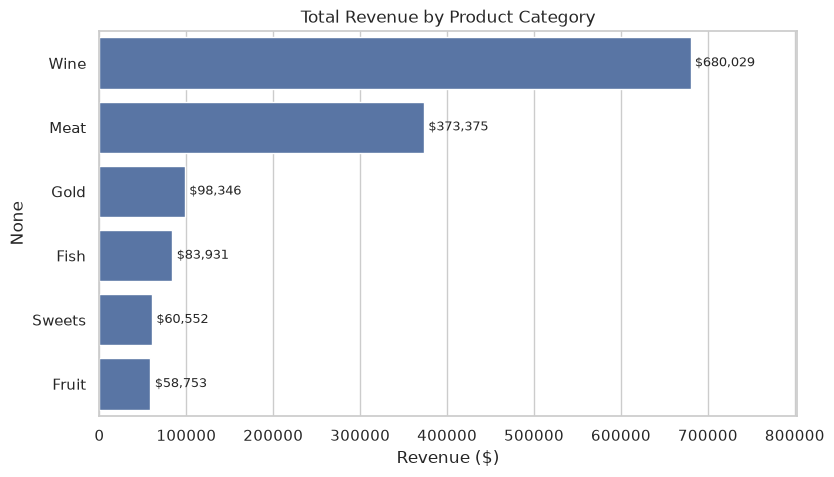

Wine + Meat share: 77.7%


In [12]:
mnt_cols = ["MntWines", "MntFruits", "MntMeatProducts",
            "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
labels = {"MntWines": "Wine", "MntFruits": "Fruit", "MntMeatProducts": "Meat",
          "MntFishProducts": "Fish", "MntSweetProducts": "Sweets", "MntGoldProds": "Gold"}

# Use df_readable if your working df is already one-hot encoded
product_rev = df_readable[mnt_cols].sum().sort_values(ascending=False)
product_rev.index = [labels[c] for c in product_rev.index]

plt.figure(figsize=(9, 5))
ax = sns.barplot(x=product_rev.values, y=product_rev.index, orient="h")
for i, v in enumerate(product_rev.values):
    ax.text(v + 5000, i, f"${v:,.0f}", va="center", fontsize=9)
plt.title("Total Revenue by Product Category")
plt.xlabel("Revenue ($)")
plt.xlim(0, product_rev.max() * 1.18)
plt.show()

print(f"Wine + Meat share: {(product_rev.iloc[0] + product_rev.iloc[1]) / product_rev.sum():.1%}")

### 8b. Age and acceptance of the last campaign

The point-biserial correlation (Pearson's r applied to a binary outcome against a continuous variable) between age and last-campaign acceptance is r = -0.019 with p = 0.38: no relationship. Customers who accepted average 44.6 years old; those who declined average 45.2. The overall acceptance rate is 14.9%.

The age-band breakdown hints at a faint U-shape, with the youngest band (18-30, 18.1%) and oldest band (61-74, 16.2%) slightly above the midlife bands near 14%, but the differences are small and untested, so no conclusion is drawn from them.

**Implication:** This is the third time age has failed to predict behavior in this analysis, after spending (r = 0.11) and channel preference (Hypothesis 1). Campaign targeting by age would waste budget; income and family composition are where the real segmentation signal lives.

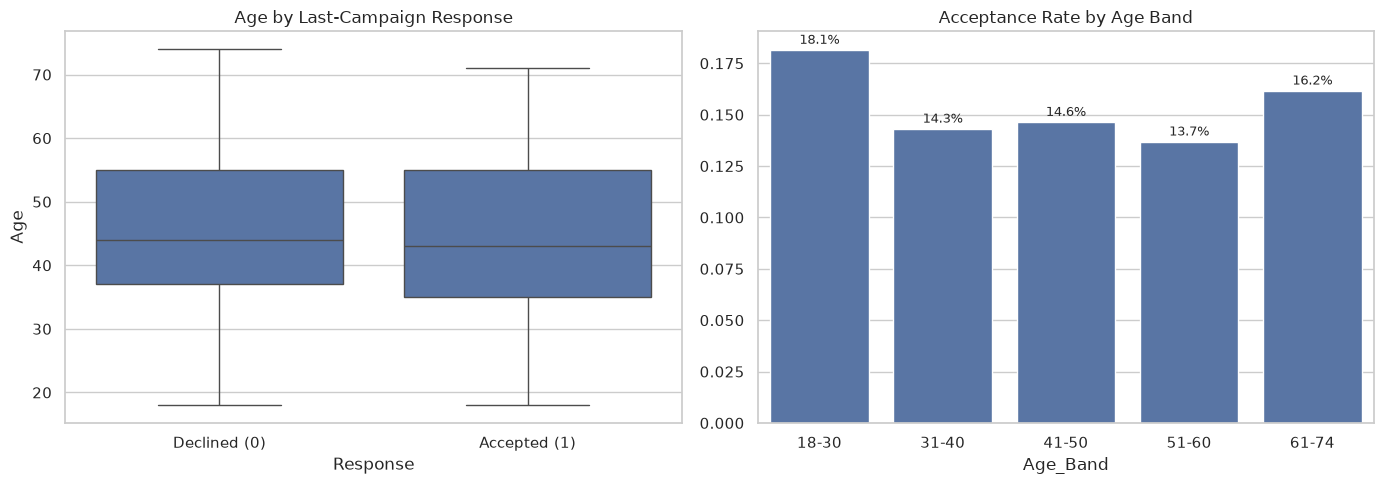

Point-biserial: r = -0.019, p = 0.3805


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_readable, x="Response", y="Age", ax=axes[0])
axes[0].set_title("Age by Last-Campaign Response")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Declined (0)", "Accepted (1)"])

df_readable["Age_Band"] = pd.cut(df_readable["Age"], bins=[17, 30, 40, 50, 60, 75],
                                 labels=["18-30", "31-40", "41-50", "51-60", "61-74"])
rate = df_readable.groupby("Age_Band", observed=True)["Response"].mean()
sns.barplot(x=rate.index, y=rate.values, ax=axes[1])
axes[1].set_title("Acceptance Rate by Age Band")
for i, v in enumerate(rate.values):
    axes[1].text(i, v + 0.003, f"{v:.1%}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

r, p = stats.pointbiserialr(df_readable["Response"], df_readable["Age"])
print(f"Point-biserial: r = {r:+.3f}, p = {p:.4f}")

### 8c. Country with the most last-campaign acceptances

**By count, Spain wins decisively: 176 acceptances**, more than triple second-place South Africa (52). This largely reflects customer base composition, since Spain contributes 1,094 of the 2,236 customers.

**By rate, the chart contains a trap worth naming.** Mexico appears to lead at 66.7%, but that figure rests on three customers, two of whom accepted; a proportion built on n = 3 is noise. Among countries with meaningful sample sizes, acceptance rates cluster between 8.8% and 16.1%, and Spain leads there too (16.1%), so Spain wins on both the count and the honest rate. India sits lowest at 8.8%, which may warrant a look at whether campaign content translates well to that market.

**Implication:** Campaign performance is fairly uniform across countries once sample size is respected. Spain is the volume engine, but there is no country whose response behavior is dramatically different enough to justify country-specific campaign redesign, with India as the only candidate for investigation.

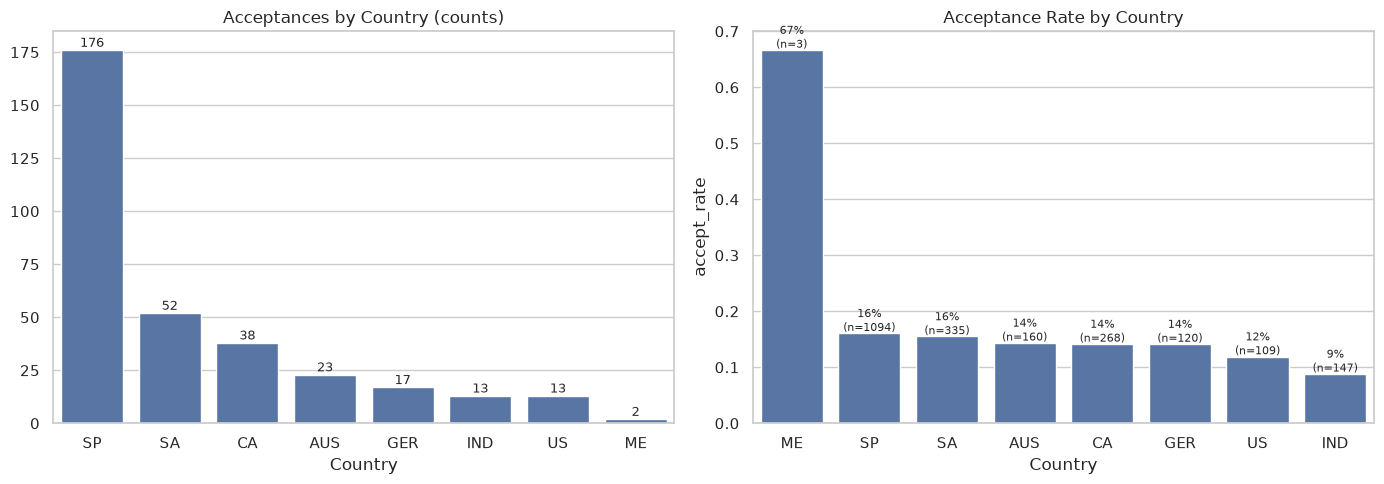

In [14]:
counts = df_readable.groupby("Country")["Response"].sum().sort_values(ascending=False)
rates = df_readable.groupby("Country")["Response"].agg(["mean", "count"])
rates.columns = ["accept_rate", "n_customers"]
rates = rates.sort_values("accept_rate", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=counts.index, y=counts.values, ax=axes[0], order=counts.index)
axes[0].set_title("Acceptances by Country (counts)")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1.5, str(int(v)), ha="center", fontsize=9)

sns.barplot(x=rates.index, y=rates["accept_rate"], ax=axes[1], order=rates.index)
axes[1].set_title("Acceptance Rate by Country")
for i, (v, n) in enumerate(zip(rates["accept_rate"], rates["n_customers"])):
    axes[1].text(i, v + 0.004, f"{v:.0%}\n(n={n})", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

### 8d. Children at home and total expenditure

The pattern is dramatic and nonlinear. Median spending is $1,189 for customers with no children at home, then collapses 74% to $306 with one child, and falls to under $100 with two or three. The first child does nearly all the work; additional children barely move an already-low floor. This is why the heatmap's r = -0.50 actually understates the relationship: correlation measures linear association, and this is a cliff.

**A confounder worth naming.** Median income for childless customers is $72K versus roughly $46K for every group with children. The spending gap therefore mixes two causes that cross-sectional data cannot separate: children genuinely consuming discretionary budget, and the childless segment simply being more affluent. Both are plausibly real; neither can be isolated here, so no per-child causal cost is claimed.

**Implication:** Combined with the product findings, the high-value customer profile is clear: affluent, no children at home, wine-led spending. Premium campaigns should target this segment, while offers to families should emphasize value and essentials rather than premium categories.

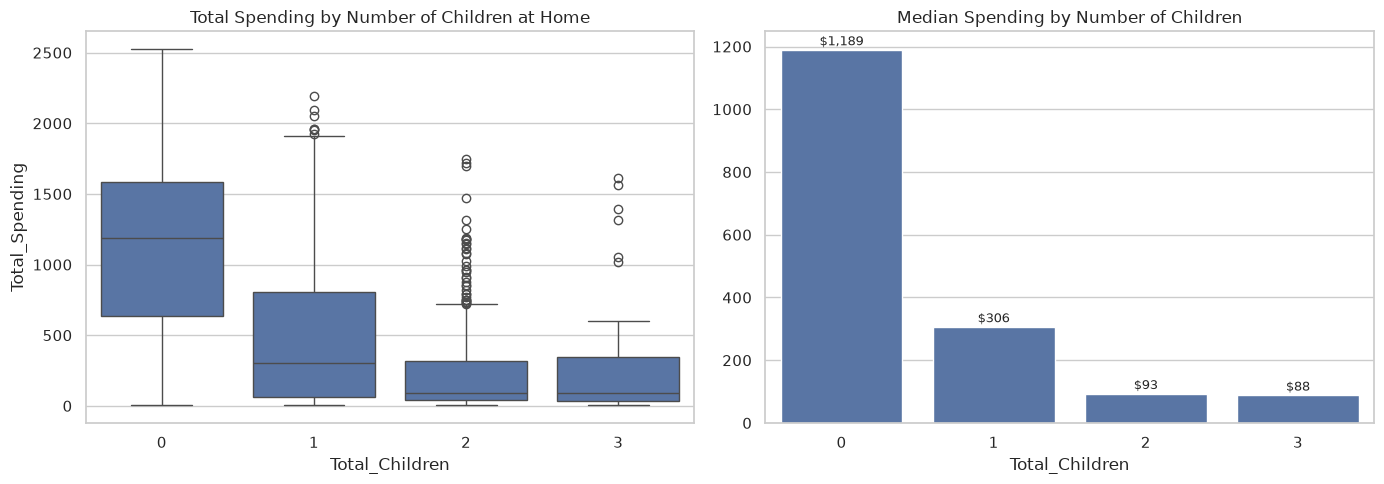

                Total_Spending   Income
Total_Children                         
0                       1189.0  72066.0
1                        306.0  47682.0
2                         93.0  44213.0
3                         88.0  46102.0


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_readable, x="Total_Children", y="Total_Spending", ax=axes[0])
axes[0].set_title("Total Spending by Number of Children at Home")

med = df_readable.groupby("Total_Children")["Total_Spending"].median()
sns.barplot(x=med.index, y=med.values, ax=axes[1])
axes[1].set_title("Median Spending by Number of Children")
for i, v in enumerate(med.values):
    axes[1].text(i, v + 15, f"${v:,.0f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

# Confounder check: income by child count
print(df_readable.groupby("Total_Children")[["Total_Spending", "Income"]].median())

### 8e. Educational background of complainers

Only 20 of 2,236 customers (0.9%) lodged a complaint in the last two years. By raw count, Graduation-educated customers lead with 14 complaints, but Graduation is also half the customer base, so counts mostly restate the base composition. The rates appear to fall with education, from 1.49% (2n Cycle) down to 0.21% (PhD), with zero complaints among Basic-educated customers.

**Why no conclusion is drawn from that gradient:** with 20 total complainers, every rate difference amounts to a handful of individuals; the PhD figure is a single person. This chart describes twenty specific customers, not a population pattern, and treating it as a segmentation insight would be over-reading noise.

**The real takeaway is the denominator:** a 0.9% complaint rate over two years either reflects genuinely high satisfaction or a complaint channel customers cannot find. The data cannot distinguish these, but the question is worth asking operationally, since a silent complaint channel hides churn risk.

Complainers: 20 of 2236 (0.9%)


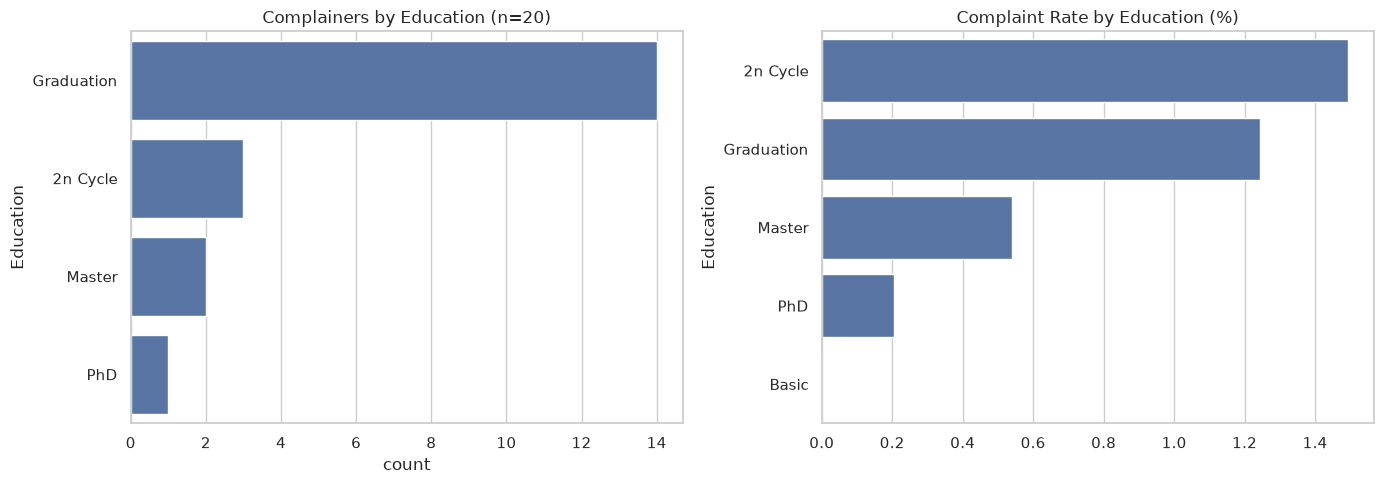

Education
2n Cycle      1.49
Graduation    1.24
Master        0.54
PhD           0.21
Basic         0.00
Name: count, dtype: float64


In [16]:
complainers = df_readable[df_readable["Complain"] == 1]
print(f"Complainers: {len(complainers)} of {len(df_readable)} ({len(complainers)/len(df_readable):.1%})")

comp_counts = complainers["Education"].value_counts()
base_counts = df_readable["Education"].value_counts()
comp_rate = (comp_counts.reindex(base_counts.index, fill_value=0)
             / base_counts * 100).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=complainers, y="Education", order=comp_counts.index, ax=axes[0])
axes[0].set_title(f"Complainers by Education (n={len(complainers)})")

sns.barplot(x=comp_rate.values, y=comp_rate.index, ax=axes[1])
axes[1].set_title("Complaint Rate by Education (%)")
plt.tight_layout()
plt.show()

print(comp_rate.round(2))

## Step 9: Conclusions

### Hypothesis test scoreboard

| # | Hypothesis | Verdict |
|---|-----------|---------|
| 1 | Older customers prefer in-store shopping | **Not supported, direction reversed.** Older customers hold a slightly *smaller* store share (49.1% vs 51.9%, p = 1.0 one-sided; the reversal itself is significant). |
| 2 | Customers with children prefer online shopping | **Supported.** Parents route 35.3% of purchases through the web vs 27.3% for non-parents (t = 14.9, p < 0.000001). Raw counts mislead here because parents buy less overall. |
| 3 | Store sales are cannibalized by other channels | **No evidence.** All channels correlate positively (store vs web r = +0.50); engaged customers use every channel. A true cannibalization test would require longitudinal data. |
| 4 | The US significantly outperforms the world in purchases | **Not established.** US mean is one purchase higher (13.5 vs 12.5) but p = 0.074 and Cohen's d = 0.14; a small effect on a small sample (n = 109). |

### What actually drives this business

1. **Wine is the business.** Wine ($680K) plus meat ($373K) carry 77.7% of product revenue; wine outsells fruit 11.6 to 1.
2. **Income drives spending** (r = 0.79), and the high-value profile is affluent, childless, and wine-led: childless customers spend a median $1,189 versus $306 with one child, though income differences between those segments confound any per-child causal claim.
3. **Age predicts nothing.** It failed on spending (r = 0.11), channel preference (H1), and campaign response (r = -0.02). Birth year is not a segmentation variable here.
4. **Heavy web browsers spend the least** (r = -0.50 between web visits and spending), suggesting a deal-hunting segment distinct from affluent low-browsing buyers.
5. **Spain is the volume engine** (1,094 of 2,236 customers, most acceptances and the highest legitimate acceptance rate at 16.1%); country-level response behavior is otherwise uniform.
6. **Complaints are near zero** (0.9% over two years), which is either high satisfaction or an invisible complaint channel.

### Recommendations

**1. Segment on income and family composition, not age.** Three separate analyses show age carries no signal. The variables that actually separate customer value are income and children at home, and both are already in the data.

**2. Lead premium campaigns with wine, aimed at the affluent childless segment.** This is where the revenue is and who buys it. Wine-and-meat pairings and premium wine offers align with revealed preference; fruit and sweets belong as basket add-ons, not campaign leads.

**3. Put parent-targeted offers in the web channel, with modest revenue expectations.** Parents demonstrably prefer online (Hypothesis 2), but their total spending is structurally lower, so the web channel is where to reach them, not where to expect premium volume.

**4. Treat channels as complements, not competitors.** With no evidence of cannibalization and strong positive cross-channel correlation, investment in channel integration (shared carts, cross-channel loyalty) fits the data better than defending stores from the website.

**5. Investigate the deal-hunter segment.** Customers with high web visits and low spending are browsing without buying. Whether they can be converted with targeted offers or are structurally low-value is answerable with a small experiment.

**6. Audit the complaint channel.** A 0.9% two-year complaint rate should be verified as genuine satisfaction rather than an unfindable feedback path, since silent dissatisfaction surfaces as churn instead of complaints.